# 0. RandomForest

- 다수의 Decision Tree를 결합한 앙상블 모델
- 각 트리는 서로 다른 데이터와 변수 조합을 통해 학습되며, 예측 결과를 회귀(평균) 또는 분류(투표)하여 최종 예측을 수행한다.
- 개별 트리의 과적합과 불안정성을 평균화하여 분산을 감소시키는 것이 목적이다.

### - Decision Tree : 편향(Bias)는 낮지만, 분산(Variance)이 매우 큰 모델.

- 데이터의 작은 변화에도 트리 구조가 크게 달라질 수 있다는 단점을 가지고 있다.

### - 이를 해결하기 위해 RandomForest (등장?) 사용.

- 정확한 트리 하나가 아닌 '틀리는 방식이 다른 트리들'을 만들도록 설계된 모델
- 개별 모델의 오류를 허용하지만 전체 모델의 일반화 성능을 향상시킨다.

## - RandomForest에서 2가지 랜덤성 

- Bootstap : 각 트리는 전체 학습 데이터에서 raw를 복원추출한다. 즉, 각 트리는 원본 데이터의 서로 다른 외곡된 버전을 보고 학습하게 된다.
- mtry(max_feature) : 일부 변수만 무작위 추출. (트리 간 상관 정도를 결정)

### Grid search : 트리의 구조적 복잡도를 탐색 for 안정화  _  개별 트리 관련 설정

### Hyperparameter tuning : RandomForest 고유의 앙상블 특성(트리 간 상관 정도)을 조절  __ 트리 간의 관계 설정

# - 정리

- RandomForest는 개별 트리 간의 상관을 낮춰 평균 효과를 극대화하는 모델이다.
- 오류를 의도적으로 허용함으로써 전체 모델의 일반화 성능을 향상시킨다.

- 랜덤성 ↑ → 상관(correlation)↓ → 앙상블 안정 But 개별 트리의 성능(strength) ↓

# 1. 이전 RandomForest 결과 Review

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 데이터 로드
df = pd.read_csv("artifacts/train_data.csv")

# 타겟 설정
target_col = "잔액_리볼빙일시불이월_target"

y = df[target_col]

# X에서 타겟 제거 후, 숫자만 남기기
X = df.drop(columns=[target_col,'발급회원번호'])


# 문자열/범주형(예: '30대') 제거 -> 숫자만 남김
X = X.select_dtypes(include=["number"])

In [3]:
# train / test 분리

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [4]:
# RandomForest 학습

rf = RandomForestRegressor(
    n_estimators=300,   # 기본값보다 살짝만 늘림 (안정성)
    max_depth=50,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [5]:
# 예측, 평가 지표

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== RandomForest (basic) ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

=== RandomForest (basic) ===
MAE  : 159761.4009
RMSE : 215620.3312
R2   : 0.7787


-----------------------------------------------------------------------------------------------------------------------

# 아래 진행의 큰 흐름

- 2 : RandomForest 전체 컬럼(224개)로 Grid Search 진행 / n_estimators = [200, 400], max_deprh = [10, 20, 50], min_samples_split = [10, 30], min_samples_leaf = [5, 10]

    → 처음 돌렸을 때 왜인지 top_feature가 적용이 안돼서 전체 컬럼으로 진행됨. 모델 조합은 모두 완료됐지만 heatmap을 그리는 부분에서 전체 컬럼을 표현할 수 없어서 오류.

- 2+@ : RandomForest top_feature으로 Grid Search 진행 / n_estimators = [200, 400], max_deprh = [10, 20, 50], min_samples_split = [10, 30], min_samples_leaf = [5, 10]

- 3 : 2+@의 randomforest_5 조합으로 전체 컬럼(224개) Grid Search 진행 / n_estimators = [400], max_deprh = [10], min_samples_split = [10], min_samples_leaf = [10]

    → best_run의 조합이 2+@와 동일한지 확인하기 위해 best_run을 출력한 randomforest_5만 다시 돌림 → 2의 randomforest_5와 비교하기 위함.

- 4 : Hyperparater tuning을 위한 핵심 요소의 여러 조합을 가지고 진행 
        
    n_estimators = [400], max_depth = [10], min_samples_leaf = [10], max_feature(mtry) = [2, 4, 6, 8, 10, 15], max_samples_(sample size) = [0.6, 0.8, 1]

# 2. RandomForest Grid Search 진행

In [27]:
import importlib
import ml_pipeline_enhanced as mlp

importlib.reload(mlp)

pipe = mlp.EnhancedMLPipeline()

2025-12-20 17:16:27 | INFO     | ================================================================================
2025-12-20 17:16:27 | INFO     | STEP 1: LOADING DATA
2025-12-20 17:16:27 | INFO     | ================================================================================
Step 1: Loading data...


Loading training data:   0%|          | 0/4 [00:00<?, ?step/s]

2025-12-20 17:16:27 | INFO     | Loading training data from: artifacts/train_data.csv


Loading test data:  25%|██▌       | 1/4 [00:01<00:03,  1.01s/step]    

2025-12-20 17:16:28 | INFO     | Loading testing data from: artifacts/test_data.csv


Encoding categorical features: 100%|██████████| 4/4 [00:02<00:00,  1.54step/s]


2025-12-20 17:16:30 | INFO     | Training set shape: (83403, 226)
2025-12-20 17:16:30 | INFO     | Testing set shape: (83403, 226)
2025-12-20 17:16:30 | INFO     | Total features: 226
2025-12-20 17:16:30 | INFO     | ================================================================================
2025-12-20 17:16:30 | INFO     | STEP 2: PREPROCESSING DATA
2025-12-20 17:16:30 | INFO     | ================================================================================
2025-12-20 17:16:30 | INFO     | Checking for missing values...
2025-12-20 17:16:30 | WARNING  | Found 2 columns with NaN values: ['연체일자_B0M', 'RV신청일자']
2025-12-20 17:16:30 | INFO     | NaN statistics (showing first 20 columns):
2025-12-20 17:16:30 | INFO     |   연체일자_B0M: Train 82368 (98.76%), Test 82599 (99.04%)
2025-12-20 17:16:30 | INFO     |   RV신청일자: Train 366 (0.44%), Test 518 (0.62%)
2025-12-20 17:16:30 | INFO     | Dropped 2 columns with NaN values
2025-12-20 17:16:30 | INFO     | Remaining features: 224
2025-12-2

Grid Search Progress:   0%|          | 0/24 [00:00<?, ?it/s]

2025-12-20 17:16:30 | INFO     | 
2025-12-20 17:16:30 | INFO     | Grid Search for RANDOM_FOREST
2025-12-20 17:16:30 | INFO     | ============================================================


Grid Search Progress:   4%|▍         | 1/24 [04:57<1:54:01, 297.44s/it]

2025-12-20 17:21:27 | INFO     | Logged run random_forest_0_9405eba0: random_forest with 224 features
2025-12-20 17:21:27 | INFO     | ✓ Run random_forest_0_9405eba0 completed | CV Score: -159913.1079 ± 683.9437


Grid Search Progress:   8%|▊         | 2/24 [14:19<2:46:03, 452.91s/it]

2025-12-20 17:30:49 | INFO     | Logged run random_forest_1_9a5c5d2a: random_forest with 224 features
2025-12-20 17:30:49 | INFO     | ✓ Run random_forest_1_9a5c5d2a completed | CV Score: -159898.4934 ± 717.4645


Grid Search Progress:  12%|█▎        | 3/24 [19:13<2:13:09, 380.45s/it]

2025-12-20 17:35:43 | INFO     | Logged run random_forest_2_941e768d: random_forest with 224 features
2025-12-20 17:35:43 | INFO     | ✓ Run random_forest_2_941e768d completed | CV Score: -159962.7466 ± 683.2351


Grid Search Progress:  17%|█▋        | 4/24 [28:36<2:30:54, 452.74s/it]

2025-12-20 17:45:07 | INFO     | Logged run random_forest_3_1ac37738: random_forest with 224 features
2025-12-20 17:45:07 | INFO     | ✓ Run random_forest_3_1ac37738 completed | CV Score: -159954.3456 ± 708.9248


Grid Search Progress:  21%|██        | 5/24 [33:28<2:04:57, 394.59s/it]

2025-12-20 17:49:58 | INFO     | Logged run random_forest_4_98e70979: random_forest with 224 features
2025-12-20 17:49:58 | INFO     | ✓ Run random_forest_4_98e70979 completed | CV Score: -159795.3743 ± 671.4919


Grid Search Progress:  25%|██▌       | 6/24 [43:10<2:17:27, 458.20s/it]

2025-12-20 17:59:40 | INFO     | Logged run random_forest_5_b846fd79: random_forest with 224 features
2025-12-20 17:59:40 | INFO     | ✓ Run random_forest_5_b846fd79 completed | CV Score: -159779.2585 ± 694.0948


Grid Search Progress:  29%|██▉       | 7/24 [47:56<1:53:52, 401.93s/it]

2025-12-20 18:04:26 | INFO     | Logged run random_forest_6_48e8aea8: random_forest with 224 features
2025-12-20 18:04:26 | INFO     | ✓ Run random_forest_6_48e8aea8 completed | CV Score: -159813.1410 ± 657.6454


Grid Search Progress:  33%|███▎      | 8/24 [57:13<2:00:20, 451.27s/it]

2025-12-20 18:13:43 | INFO     | Logged run random_forest_7_f01761af: random_forest with 224 features
2025-12-20 18:13:43 | INFO     | ✓ Run random_forest_7_f01761af completed | CV Score: -159804.2377 ± 684.0811


Grid Search Progress:  38%|███▊      | 9/24 [1:04:14<1:50:28, 441.87s/it]

2025-12-20 18:20:44 | INFO     | Logged run random_forest_8_eb9519e7: random_forest with 224 features
2025-12-20 18:20:44 | INFO     | ✓ Run random_forest_8_eb9519e7 completed | CV Score: -159483.1310 ± 813.9207


Grid Search Progress:  42%|████▏     | 10/24 [1:18:19<2:12:07, 566.25s/it]

2025-12-20 18:34:49 | INFO     | Logged run random_forest_9_1d8c1135: random_forest with 224 features
2025-12-20 18:34:49 | INFO     | ✓ Run random_forest_9_1d8c1135 completed | CV Score: -159315.3839 ± 787.8814


Grid Search Progress:  46%|████▌     | 11/24 [1:24:56<1:51:29, 514.55s/it]

2025-12-20 18:41:26 | INFO     | Logged run random_forest_10_a4b3f381: random_forest with 224 features
2025-12-20 18:41:26 | INFO     | ✓ Run random_forest_10_a4b3f381 completed | CV Score: -159435.9140 ± 783.5027


Grid Search Progress:  50%|█████     | 12/24 [1:37:50<1:58:41, 593.48s/it]

2025-12-20 18:54:20 | INFO     | Logged run random_forest_11_23613e7e: random_forest with 224 features
2025-12-20 18:54:20 | INFO     | ✓ Run random_forest_11_23613e7e completed | CV Score: -159327.8829 ± 786.4519


Grid Search Progress:  54%|█████▍    | 13/24 [1:44:07<1:36:48, 528.04s/it]

2025-12-20 19:00:38 | INFO     | Logged run random_forest_12_802a326a: random_forest with 224 features
2025-12-20 19:00:38 | INFO     | ✓ Run random_forest_12_802a326a completed | CV Score: -159178.5611 ± 730.2924


Grid Search Progress:  58%|█████▊    | 14/24 [1:56:39<1:39:16, 595.67s/it]

2025-12-20 19:13:10 | INFO     | Logged run random_forest_13_e77508be: random_forest with 224 features
2025-12-20 19:13:10 | INFO     | ✓ Run random_forest_13_e77508be completed | CV Score: -159118.5953 ± 750.6200


Grid Search Progress:  62%|██████▎   | 15/24 [2:02:51<1:19:13, 528.20s/it]

2025-12-20 19:19:22 | INFO     | Logged run random_forest_14_b508b76f: random_forest with 224 features
2025-12-20 19:19:22 | INFO     | ✓ Run random_forest_14_b508b76f completed | CV Score: -159182.9297 ± 713.6419


Grid Search Progress:  67%|██████▋   | 16/24 [2:14:52<1:18:09, 586.14s/it]

2025-12-20 19:31:22 | INFO     | Logged run random_forest_15_a708407e: random_forest with 224 features
2025-12-20 19:31:22 | INFO     | ✓ Run random_forest_15_a708407e completed | CV Score: -159146.1495 ± 747.6062


Grid Search Progress:  71%|███████   | 17/24 [2:22:16<1:03:24, 543.50s/it]

2025-12-20 19:38:47 | INFO     | Logged run random_forest_16_50f347f2: random_forest with 224 features
2025-12-20 19:38:47 | INFO     | ✓ Run random_forest_16_50f347f2 completed | CV Score: -159513.1627 ± 824.1108


Grid Search Progress:  75%|███████▌  | 18/24 [2:36:35<1:03:50, 638.33s/it]

2025-12-20 19:53:06 | INFO     | Logged run random_forest_17_919939a9: random_forest with 224 features
2025-12-20 19:53:06 | INFO     | ✓ Run random_forest_17_919939a9 completed | CV Score: -159336.2881 ± 795.6956


Grid Search Progress:  79%|███████▉  | 19/24 [2:43:25<47:28, 569.70s/it]  

2025-12-20 19:59:55 | INFO     | Logged run random_forest_18_ebba2707: random_forest with 224 features
2025-12-20 19:59:55 | INFO     | ✓ Run random_forest_18_ebba2707 completed | CV Score: -159446.4960 ± 791.4546


Grid Search Progress:  83%|████████▎ | 20/24 [2:56:59<42:52, 643.10s/it]

2025-12-20 20:13:30 | INFO     | Logged run random_forest_19_b8c16c83: random_forest with 224 features
2025-12-20 20:13:30 | INFO     | ✓ Run random_forest_19_b8c16c83 completed | CV Score: -159332.1133 ± 789.6718


Grid Search Progress:  88%|████████▊ | 21/24 [3:03:24<28:16, 565.60s/it]

2025-12-20 20:19:55 | INFO     | Logged run random_forest_20_5ae063de: random_forest with 224 features
2025-12-20 20:19:55 | INFO     | ✓ Run random_forest_20_5ae063de completed | CV Score: -159173.2016 ± 734.9280


Grid Search Progress:  92%|█████████▏| 22/24 [3:15:48<20:38, 619.10s/it]

2025-12-20 20:32:18 | INFO     | Logged run random_forest_21_c3a11d1b: random_forest with 224 features
2025-12-20 20:32:18 | INFO     | ✓ Run random_forest_21_c3a11d1b completed | CV Score: -159118.0293 ± 755.8259


Grid Search Progress:  96%|█████████▌| 23/24 [3:22:02<09:05, 545.68s/it]

2025-12-20 20:38:33 | INFO     | Logged run random_forest_22_019e7191: random_forest with 224 features
2025-12-20 20:38:33 | INFO     | ✓ Run random_forest_22_019e7191 completed | CV Score: -159182.0308 ± 718.7759


Grid Search Progress: 100%|██████████| 24/24 [3:34:05<00:00, 535.25s/it]


2025-12-20 20:50:36 | INFO     | Logged run random_forest_23_81b077c4: random_forest with 224 features
2025-12-20 20:50:36 | INFO     | ✓ Run random_forest_23_81b077c4 completed | CV Score: -159147.3987 ± 752.9702
2025-12-20 20:50:36 | INFO     | ================================================================================
2025-12-20 20:50:36 | INFO     | STEP 5: GENERATING VISUALIZATIONS
2025-12-20 20:50:36 | INFO     | ================================================================================
2025-12-20 20:50:37 | INFO     | Saved metrics_comparison.png
2025-12-20 20:50:38 | INFO     | Saved model_comparison.png
2025-12-20 20:50:39 | INFO     | Saved training_time_vs_performance.png
2025-12-20 20:50:39 | ERROR    | Pipeline failed: The number of FixedLocator locations (56), usually from a call to set_ticks, does not match the number of labels (224).


ValueError: The number of FixedLocator locations (56), usually from a call to set_ticks, does not match the number of labels (224).

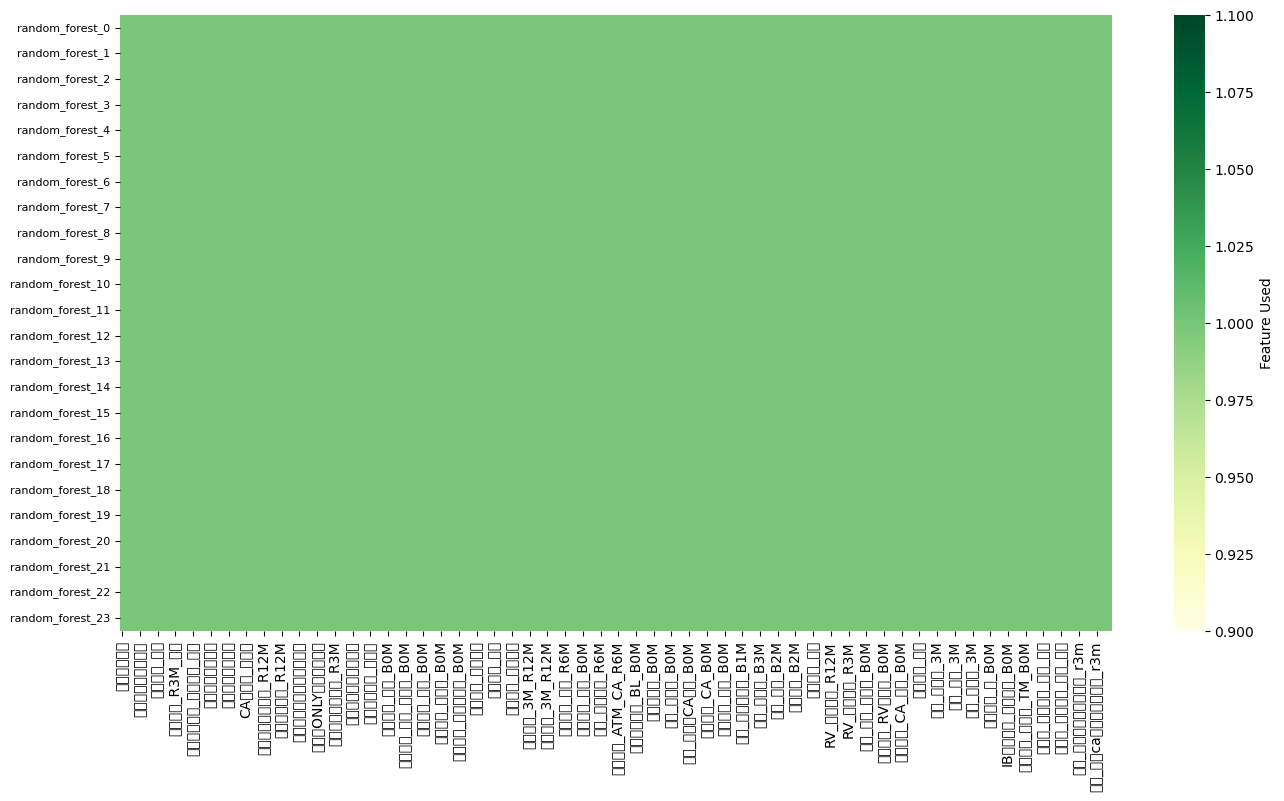

In [28]:
pipe.run_pipeline()

## ml_pipeline_enhanced 코드로 RandomForest의 결과만 확인하려고 

## 코드를 일부 수정하고 진행했는데

## top_features만 진행된 것이 아닌 모든 컬럼을 가지고 진행된 것으로 확인. 

## 오류는 모든 컬럼명을 기입할 수 없어서 시각화 부분에서 발생.

## 이후 아래에서 코드 수정 후 재진행.

------------------------------------------------------------------------------------------------------------------------------

# 2+@. top_features만 가지고 RandomForest grid search 재진행

In [18]:
import importlib
import ml_pipeline_enhanced as mlp

importlib.reload(mlp)

pipe = mlp.EnhancedMLPipeline()

In [21]:
# top_features를 따로 지정

top_features = [
    "잔액_리볼빙일시불이월_B0M",   
    "월중평잔_RV일시불",
    "평잔_RV일시불_3M",
    "이용금액_신용_B0M",
    "잔액_신판평균한도소진율_r6m",
    "카드이용한도금액",
    "RV_최대잔액_R12M",
    "잔액_B0M"
]

pipe = mlp.EnhancedMLPipeline()
pipe.select_columns_for_training(top_features)
pipe.run_pipeline()


2025-12-21 03:10:00 | INFO     | Manually set columns for training: ['잔액_리볼빙일시불이월_B0M', '월중평잔_RV일시불', '평잔_RV일시불_3M', '이용금액_신용_B0M', '잔액_신판평균한도소진율_r6m', '카드이용한도금액', 'RV_최대잔액_R12M', '잔액_B0M']
2025-12-21 03:10:00 | INFO     | ================================================================================
2025-12-21 03:10:00 | INFO     | STEP 1: LOADING DATA
2025-12-21 03:10:00 | INFO     | ================================================================================
Step 1: Loading data...


Loading training data:   0%|          | 0/4 [00:00<?, ?step/s]

2025-12-21 03:10:00 | INFO     | Loading training data from: artifacts/train_data.csv


Loading test data:  25%|██▌       | 1/4 [00:01<00:03,  1.25s/step]    

2025-12-21 03:10:01 | INFO     | Loading testing data from: artifacts/test_data.csv


Encoding categorical features: 100%|██████████| 4/4 [00:02<00:00,  1.59step/s]


2025-12-21 03:10:02 | INFO     | Using user-provided columns for training: ['잔액_리볼빙일시불이월_B0M', '월중평잔_RV일시불', '평잔_RV일시불_3M', '이용금액_신용_B0M', '잔액_신판평균한도소진율_r6m', '카드이용한도금액', 'RV_최대잔액_R12M', '잔액_B0M']
2025-12-21 03:10:02 | INFO     | Training set shape: (83403, 8)
2025-12-21 03:10:02 | INFO     | Testing set shape: (83403, 8)
2025-12-21 03:10:02 | INFO     | Total features: 8
2025-12-21 03:10:02 | INFO     | ================================================================================
2025-12-21 03:10:02 | INFO     | STEP 2: PREPROCESSING DATA
2025-12-21 03:10:02 | INFO     | ================================================================================
2025-12-21 03:10:02 | INFO     | Checking for missing values...
2025-12-21 03:10:02 | INFO     | No missing values found in the data
2025-12-21 03:10:02 | INFO     | Data scaled using StandardScaler
2025-12-21 03:10:02 | INFO     | Final training shape: (83403, 8)
2025-12-21 03:10:02 | INFO     | Final test shape: (83403, 8)
2025-12-21

Grid Search Progress:   0%|          | 0/24 [00:00<?, ?it/s]

2025-12-21 03:10:02 | INFO     | 
2025-12-21 03:10:02 | INFO     | Grid Search for RANDOM_FOREST
2025-12-21 03:10:02 | INFO     | ============================================================


Grid Search Progress:   4%|▍         | 1/24 [01:28<33:47, 88.14s/it]

2025-12-21 03:11:31 | INFO     | Logged run random_forest_0_9405eba0: random_forest with 8 features
2025-12-21 03:11:31 | INFO     | ✓ Run random_forest_0_9405eba0 completed | CV Score: -170845.6367 ± 997.3046


Grid Search Progress:   8%|▊         | 2/24 [06:42<1:21:07, 221.25s/it]

2025-12-21 03:16:45 | INFO     | Logged run random_forest_1_9a5c5d2a: random_forest with 8 features
2025-12-21 03:16:45 | INFO     | ✓ Run random_forest_1_9a5c5d2a completed | CV Score: -170817.4071 ± 1009.1946


Grid Search Progress:  12%|█▎        | 3/24 [08:49<1:02:17, 177.98s/it]

2025-12-21 03:18:52 | INFO     | Logged run random_forest_2_941e768d: random_forest with 8 features
2025-12-21 03:18:52 | INFO     | ✓ Run random_forest_2_941e768d completed | CV Score: -170853.1162 ± 999.1807


Grid Search Progress:  17%|█▋        | 4/24 [13:11<1:10:25, 211.25s/it]

2025-12-21 03:23:14 | INFO     | Logged run random_forest_3_1ac37738: random_forest with 8 features
2025-12-21 03:23:14 | INFO     | ✓ Run random_forest_3_1ac37738 completed | CV Score: -170828.6078 ± 1010.7746


Grid Search Progress:  21%|██        | 5/24 [16:39<1:06:31, 210.09s/it]

2025-12-21 03:26:42 | INFO     | Logged run random_forest_4_98e70979: random_forest with 8 features
2025-12-21 03:26:42 | INFO     | ✓ Run random_forest_4_98e70979 completed | CV Score: -170786.4846 ± 998.3285


Grid Search Progress:  25%|██▌       | 6/24 [23:24<1:22:57, 276.52s/it]

2025-12-21 03:33:27 | INFO     | Logged run random_forest_5_b846fd79: random_forest with 8 features
2025-12-21 03:33:27 | INFO     | ✓ Run random_forest_5_b846fd79 completed | CV Score: -170777.5182 ± 1024.3837


Grid Search Progress:  29%|██▉       | 7/24 [26:54<1:12:09, 254.68s/it]

2025-12-21 03:36:57 | INFO     | Logged run random_forest_6_48e8aea8: random_forest with 8 features
2025-12-21 03:36:57 | INFO     | ✓ Run random_forest_6_48e8aea8 completed | CV Score: -170791.0961 ± 1000.3441


Grid Search Progress:  33%|███▎      | 8/24 [33:35<1:20:19, 301.22s/it]

2025-12-21 03:43:38 | INFO     | Logged run random_forest_7_f01761af: random_forest with 8 features
2025-12-21 03:43:38 | INFO     | ✓ Run random_forest_7_f01761af completed | CV Score: -170779.9778 ± 1025.3483


Grid Search Progress:  38%|███▊      | 9/24 [36:33<1:05:43, 262.87s/it]

2025-12-21 03:46:36 | INFO     | Logged run random_forest_8_eb9519e7: random_forest with 8 features
2025-12-21 03:46:36 | INFO     | ✓ Run random_forest_8_eb9519e7 completed | CV Score: -172126.6794 ± 774.0282


Grid Search Progress:  42%|████▏     | 10/24 [44:31<1:16:46, 329.01s/it]

2025-12-21 03:54:33 | INFO     | Logged run random_forest_9_1d8c1135: random_forest with 8 features
2025-12-21 03:54:33 | INFO     | ✓ Run random_forest_9_1d8c1135 completed | CV Score: -171993.1710 ± 786.1723


Grid Search Progress:  46%|████▌     | 11/24 [48:21<1:04:43, 298.71s/it]

2025-12-21 03:58:24 | INFO     | Logged run random_forest_10_a4b3f381: random_forest with 8 features
2025-12-21 03:58:24 | INFO     | ✓ Run random_forest_10_a4b3f381 completed | CV Score: -171507.5347 ± 792.5549


Grid Search Progress:  50%|█████     | 12/24 [55:42<1:08:24, 342.08s/it]

2025-12-21 04:05:45 | INFO     | Logged run random_forest_11_23613e7e: random_forest with 8 features
2025-12-21 04:05:45 | INFO     | ✓ Run random_forest_11_23613e7e completed | CV Score: -171417.7425 ± 802.3712


Grid Search Progress:  54%|█████▍    | 13/24 [59:43<57:05, 311.45s/it]  

2025-12-21 04:09:46 | INFO     | Logged run random_forest_12_802a326a: random_forest with 8 features
2025-12-21 04:09:46 | INFO     | ✓ Run random_forest_12_802a326a completed | CV Score: -171490.6774 ± 854.4241


Grid Search Progress:  58%|█████▊    | 14/24 [1:07:15<59:01, 354.11s/it]

2025-12-21 04:17:18 | INFO     | Logged run random_forest_13_e77508be: random_forest with 8 features
2025-12-21 04:17:18 | INFO     | ✓ Run random_forest_13_e77508be completed | CV Score: -171442.8783 ± 871.0444


Grid Search Progress:  62%|██████▎   | 15/24 [1:10:51<46:52, 312.47s/it]

2025-12-21 04:20:54 | INFO     | Logged run random_forest_14_b508b76f: random_forest with 8 features
2025-12-21 04:20:54 | INFO     | ✓ Run random_forest_14_b508b76f completed | CV Score: -171314.0537 ± 876.5481


Grid Search Progress:  67%|██████▋   | 16/24 [1:18:00<46:20, 347.54s/it]

2025-12-21 04:28:03 | INFO     | Logged run random_forest_15_a708407e: random_forest with 8 features
2025-12-21 04:28:03 | INFO     | ✓ Run random_forest_15_a708407e completed | CV Score: -171263.8245 ± 894.4689


Grid Search Progress:  71%|███████   | 17/24 [1:22:10<37:07, 318.21s/it]

2025-12-21 04:32:13 | INFO     | Logged run random_forest_16_50f347f2: random_forest with 8 features
2025-12-21 04:32:13 | INFO     | ✓ Run random_forest_16_50f347f2 completed | CV Score: -172290.6151 ± 777.9741


Grid Search Progress:  75%|███████▌  | 18/24 [1:29:58<36:18, 363.05s/it]

2025-12-21 04:40:01 | INFO     | Logged run random_forest_17_919939a9: random_forest with 8 features
2025-12-21 04:40:01 | INFO     | ✓ Run random_forest_17_919939a9 completed | CV Score: -172140.0439 ± 777.3578


Grid Search Progress:  79%|███████▉  | 19/24 [1:33:47<26:53, 322.73s/it]

2025-12-21 04:43:50 | INFO     | Logged run random_forest_18_ebba2707: random_forest with 8 features
2025-12-21 04:43:50 | INFO     | ✓ Run random_forest_18_ebba2707 completed | CV Score: -171559.0292 ± 793.8604


Grid Search Progress:  83%|████████▎ | 20/24 [1:41:11<23:57, 359.33s/it]

2025-12-21 04:51:14 | INFO     | Logged run random_forest_19_b8c16c83: random_forest with 8 features
2025-12-21 04:51:14 | INFO     | ✓ Run random_forest_19_b8c16c83 completed | CV Score: -171466.7813 ± 803.2021


Grid Search Progress:  88%|████████▊ | 21/24 [1:44:49<15:50, 316.81s/it]

2025-12-21 04:54:52 | INFO     | Logged run random_forest_20_5ae063de: random_forest with 8 features
2025-12-21 04:54:52 | INFO     | ✓ Run random_forest_20_5ae063de completed | CV Score: -171522.3096 ± 849.2822


Grid Search Progress:  92%|█████████▏| 22/24 [1:51:50<11:36, 348.19s/it]

2025-12-21 05:01:53 | INFO     | Logged run random_forest_21_c3a11d1b: random_forest with 8 features
2025-12-21 05:01:53 | INFO     | ✓ Run random_forest_21_c3a11d1b completed | CV Score: -171470.9848 ± 864.4586


Grid Search Progress:  96%|█████████▌| 23/24 [1:55:29<05:09, 309.39s/it]

2025-12-21 05:05:32 | INFO     | Logged run random_forest_22_019e7191: random_forest with 8 features
2025-12-21 05:05:32 | INFO     | ✓ Run random_forest_22_019e7191 completed | CV Score: -171333.2259 ± 873.8867


Grid Search Progress: 100%|██████████| 24/24 [2:02:35<00:00, 306.46s/it]


2025-12-21 05:12:38 | INFO     | Logged run random_forest_23_81b077c4: random_forest with 8 features
2025-12-21 05:12:38 | INFO     | ✓ Run random_forest_23_81b077c4 completed | CV Score: -171280.3555 ± 890.2633
2025-12-21 05:12:38 | INFO     | ================================================================================
2025-12-21 05:12:38 | INFO     | STEP 5: GENERATING VISUALIZATIONS
2025-12-21 05:12:38 | INFO     | ================================================================================
2025-12-21 05:12:40 | INFO     | Saved metrics_comparison.png
2025-12-21 05:12:41 | INFO     | Saved model_comparison.png
2025-12-21 05:12:42 | INFO     | Saved training_time_vs_performance.png
2025-12-21 05:12:43 | INFO     | Saved feature_usage_heatmap.png
2025-12-21 05:12:43 | INFO     | Saved cv_scores_distribution.png
2025-12-21 05:12:45 | INFO     | Saved runs_summary_table.png
2025-12-21 05:12:45 | INFO     | Visualizations generated successfully
2025-12-21 05:12:45 | INFO     | ==

### 먼저 전반적인 CV Score 값을 대략적으로 살펴보면 

### 전체 컬럼 : 약 -159,000 대.  top_features : 약 - 171,600 (500원 정도의 오차)

### 전반적인 CV Score 값이 전체 컬럼을 기준으로 했을 때 더 좋음. → 결과를 버리긴 아까워 이용하고자함.

### 두 결과의 Grid Search 조합은 동일하고 컬럼 수만 다르니

### top_features를 통해 나온 조합표를 기준으로 

### 전체 컬럼과 top_features의 RandomForest의 인덱스가 동일하면 동일한 조합을 사용했다고 가정.

### top_features에서 5번 인덱스가 best_run으로 채택. -> 트리의 복잡도는 5번 인덱스일 때 가장 안정.

### 전체 컬럼을 다시 다 돌리는 것은 시간적으로 여유가 없으니 5번 인덱스의 조합으로만 RF를 돌려보고자 한다.



__________________________________________________________________________________________________________________________________________________

# 3. 전체 컬럼의 best_run을 검증하기 위해
# randomforest_5의 CV Score와 2에서의 randomforest_5의 결과를 비교
# 값이 비슷하면 전체 컬럼 버전의 randomforest_5를 best_run으로 채택.

In [4]:
import importlib
import ml_pipeline_enhanced as mlp

importlib.reload(mlp)

pipe = mlp.EnhancedMLPipeline()

2025-12-21 08:29:24 | INFO     | ================================================================================
2025-12-21 08:29:24 | INFO     | STEP 1: LOADING DATA
2025-12-21 08:29:24 | INFO     | ================================================================================
Step 1: Loading data...


Loading training data:   0%|          | 0/4 [00:00<?, ?step/s]

2025-12-21 08:29:24 | INFO     | Loading training data from: artifacts/train_data.csv


Loading test data:  25%|██▌       | 1/4 [00:01<00:03,  1.31s/step]    

2025-12-21 08:29:25 | INFO     | Loading testing data from: artifacts/test_data.csv


Encoding categorical features: 100%|██████████| 4/4 [00:03<00:00,  1.25step/s]


2025-12-21 08:29:27 | INFO     | Training set shape: (83403, 226)
2025-12-21 08:29:27 | INFO     | Testing set shape: (83403, 226)
2025-12-21 08:29:27 | INFO     | Total features: 226
2025-12-21 08:29:27 | INFO     | ================================================================================
2025-12-21 08:29:27 | INFO     | STEP 2: PREPROCESSING DATA
2025-12-21 08:29:27 | INFO     | ================================================================================
2025-12-21 08:29:27 | INFO     | Checking for missing values...
2025-12-21 08:29:27 | WARNING  | Found 2 columns with NaN values: ['연체일자_B0M', 'RV신청일자']
2025-12-21 08:29:27 | INFO     | NaN statistics (showing first 20 columns):
2025-12-21 08:29:27 | INFO     |   연체일자_B0M: Train 82368 (98.76%), Test 82599 (99.04%)
2025-12-21 08:29:27 | INFO     |   RV신청일자: Train 366 (0.44%), Test 518 (0.62%)
2025-12-21 08:29:27 | INFO     | Dropped 2 columns with NaN values
2025-12-21 08:29:27 | INFO     | Remaining features: 224
2025-12-2

Grid Search Progress:   0%|          | 0/1 [00:00<?, ?it/s]

2025-12-21 08:29:28 | INFO     | 
2025-12-21 08:29:28 | INFO     | Grid Search for RANDOM_FOREST
2025-12-21 08:29:28 | INFO     | ============================================================


Grid Search Progress: 100%|██████████| 1/1 [41:11<00:00, 2471.22s/it]


2025-12-21 09:10:39 | INFO     | Logged run random_forest_0_b846fd79: random_forest with 224 features
2025-12-21 09:10:39 | INFO     | ✓ Run random_forest_0_b846fd79 completed | CV Score: -159776.9757 ± 684.3636
2025-12-21 09:10:39 | INFO     | ================================================================================
2025-12-21 09:10:39 | INFO     | STEP 5: GENERATING VISUALIZATIONS
2025-12-21 09:10:39 | INFO     | ================================================================================
2025-12-21 09:10:40 | INFO     | Saved metrics_comparison.png
2025-12-21 09:10:41 | INFO     | Saved model_comparison.png
2025-12-21 09:10:42 | INFO     | Saved training_time_vs_performance.png
2025-12-21 09:10:42 | ERROR    | Pipeline failed: The number of FixedLocator locations (56), usually from a call to set_ticks, does not match the number of labels (224).


ValueError: The number of FixedLocator locations (56), usually from a call to set_ticks, does not match the number of labels (224).

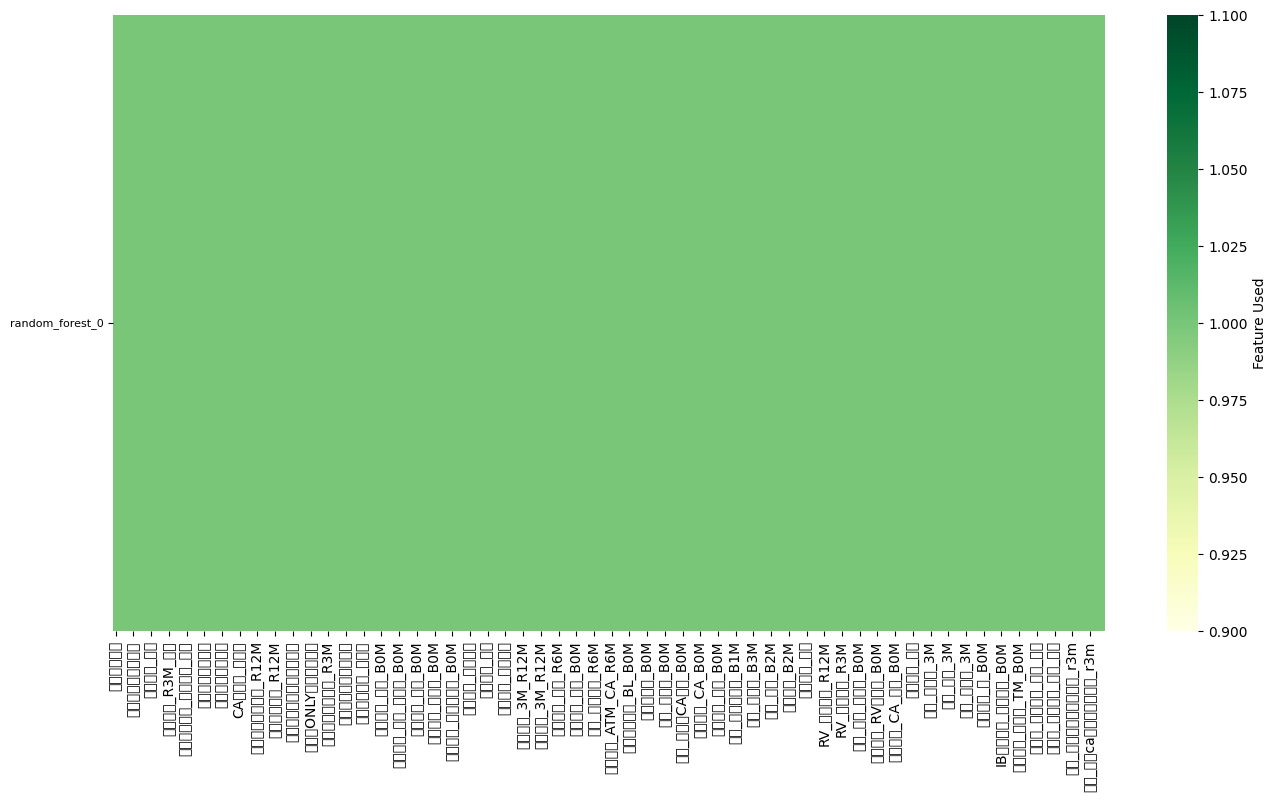

In [5]:
pipe.run_pipeline()

### 3번 결과 : CV Score: -159776.9757 ± 684.3636 
### 2번 결과와 3번 결과가 유사 → 2번의 결과가 2+@의 radomforest_5의 조합을 사용했다고 판단.

---------------------------------------------------------------------------------------------------------------------------------------------------

# 4. Hyperparameter Tuning 

- Hyperparameters and Tuning Strategies for Random Forest (Philipp Probst, Marvin Wright, Anne-Laure Boulesteix) 논문을 참고.

- Hyperparameter tuning의 핵심은 '개별 트리의 강도(strength)와 트리 간의 상관(correlation) 간의 관계'이다.

- 랜덤성이 증가할수록 트리 간의 상관은 감소하고 RF의 앙상블이 안정된다. 하지만 개별 트리의 성능(strength)이 떨어지게 된다.

### 2번 결과의 randomforest를 이용하여 hyperparameter tuning을 진행 → baic ver 과 tuning ver의 차이를 비교

- n_estimator = 400, max_deep = 10, min_samples_leaf = 10
- max_feature(mtry) = [2, 4, 6, 8, 10, 15], max_samples_(sample size) = [0.6, 0.8, 1]

In [34]:
import importlib
import ml_pipeline_enhanced as mlp

importlib.reload(mlp)

pipe = mlp.EnhancedMLPipeline()

2025-12-21 12:03:28 | INFO     | ================================================================================
2025-12-21 12:03:28 | INFO     | STEP 1: LOADING DATA
2025-12-21 12:03:28 | INFO     | ================================================================================
Step 1: Loading data...


Loading training data:   0%|          | 0/4 [00:00<?, ?step/s]

2025-12-21 12:03:28 | INFO     | Loading training data from: artifacts/train_data.csv


Loading test data:  25%|██▌       | 1/4 [00:03<00:09,  3.32s/step]    

2025-12-21 12:03:31 | INFO     | Loading testing data from: artifacts/test_data.csv


Encoding categorical features: 100%|██████████| 4/4 [00:07<00:00,  1.91s/step]


2025-12-21 12:03:36 | INFO     | Training set shape: (83403, 226)
2025-12-21 12:03:36 | INFO     | Testing set shape: (83403, 226)
2025-12-21 12:03:36 | INFO     | Total features: 226
2025-12-21 12:03:36 | INFO     | ================================================================================
2025-12-21 12:03:36 | INFO     | STEP 2: PREPROCESSING DATA
2025-12-21 12:03:36 | INFO     | ================================================================================
2025-12-21 12:03:36 | INFO     | Checking for missing values...
2025-12-21 12:03:36 | WARNING  | Found 2 columns with NaN values: ['연체일자_B0M', 'RV신청일자']
2025-12-21 12:03:36 | INFO     | NaN statistics (showing first 20 columns):
2025-12-21 12:03:36 | INFO     |   연체일자_B0M: Train 82368 (98.76%), Test 82599 (99.04%)
2025-12-21 12:03:36 | INFO     |   RV신청일자: Train 366 (0.44%), Test 518 (0.62%)
2025-12-21 12:03:36 | INFO     | Dropped 2 columns with NaN values
2025-12-21 12:03:36 | INFO     | Remaining features: 224
2025-12-2

Grid Search Progress:   0%|          | 0/18 [00:00<?, ?it/s]

2025-12-21 12:03:37 | INFO     | 
2025-12-21 12:03:37 | INFO     | Grid Search for RANDOM_FOREST
2025-12-21 12:03:37 | INFO     | ============================================================


Grid Search Progress:   6%|▌         | 1/18 [00:16<04:37, 16.33s/it]

2025-12-21 12:03:53 | INFO     | Logged run random_forest_0_edb3d0c4: random_forest with 224 features
2025-12-21 12:03:53 | INFO     | ✓ Run random_forest_0_edb3d0c4 completed | CV Score: -198423.1042 ± 1724.4556


Grid Search Progress:  11%|█         | 2/18 [00:37<05:11, 19.46s/it]

2025-12-21 12:04:15 | INFO     | Logged run random_forest_1_ef425aec: random_forest with 224 features
2025-12-21 12:04:15 | INFO     | ✓ Run random_forest_1_ef425aec completed | CV Score: -197808.0638 ± 1448.3380


Grid Search Progress:  17%|█▋        | 3/18 [01:01<05:21, 21.42s/it]

2025-12-21 12:04:38 | INFO     | Logged run random_forest_2_fbea0948: random_forest with 224 features
2025-12-21 12:04:38 | INFO     | ✓ Run random_forest_2_fbea0948 completed | CV Score: -198002.9656 ± 1839.2250


Grid Search Progress:  22%|██▏       | 4/18 [01:33<05:56, 25.47s/it]

2025-12-21 12:05:10 | INFO     | Logged run random_forest_3_afe4ed09: random_forest with 224 features
2025-12-21 12:05:10 | INFO     | ✓ Run random_forest_3_afe4ed09 completed | CV Score: -167177.7720 ± 989.6630


Grid Search Progress:  28%|██▊       | 5/18 [02:20<07:10, 33.09s/it]

2025-12-21 12:05:57 | INFO     | Logged run random_forest_4_869c70f6: random_forest with 224 features
2025-12-21 12:05:57 | INFO     | ✓ Run random_forest_4_869c70f6 completed | CV Score: -166947.9173 ± 946.8182


Grid Search Progress:  33%|███▎      | 6/18 [03:22<08:35, 42.98s/it]

2025-12-21 12:06:59 | INFO     | Logged run random_forest_5_73b49b55: random_forest with 224 features
2025-12-21 12:06:59 | INFO     | ✓ Run random_forest_5_73b49b55 completed | CV Score: -166652.4246 ± 1265.7792


Grid Search Progress:  39%|███▉      | 7/18 [04:09<08:08, 44.44s/it]

2025-12-21 12:07:46 | INFO     | Logged run random_forest_6_ef5c949e: random_forest with 224 features
2025-12-21 12:07:46 | INFO     | ✓ Run random_forest_6_ef5c949e completed | CV Score: -160550.0435 ± 1018.4914


Grid Search Progress:  44%|████▍     | 8/18 [05:06<08:03, 48.31s/it]

2025-12-21 12:08:43 | INFO     | Logged run random_forest_7_50a9ebde: random_forest with 224 features
2025-12-21 12:08:43 | INFO     | ✓ Run random_forest_7_50a9ebde completed | CV Score: -160469.8483 ± 984.0197


Grid Search Progress:  50%|█████     | 9/18 [06:42<09:28, 63.16s/it]

2025-12-21 12:10:19 | INFO     | Logged run random_forest_8_70e0fca6: random_forest with 224 features
2025-12-21 12:10:19 | INFO     | ✓ Run random_forest_8_70e0fca6 completed | CV Score: -160465.0911 ± 1049.3625


Grid Search Progress:  56%|█████▌    | 10/18 [07:40<08:12, 61.57s/it]

2025-12-21 12:11:17 | INFO     | Logged run random_forest_9_c3a6ef96: random_forest with 224 features
2025-12-21 12:11:17 | INFO     | ✓ Run random_forest_9_c3a6ef96 completed | CV Score: -158943.2976 ± 902.9508


Grid Search Progress:  61%|██████    | 11/18 [09:08<08:07, 69.68s/it]

2025-12-21 12:12:45 | INFO     | Logged run random_forest_10_35f9e4ea: random_forest with 224 features
2025-12-21 12:12:45 | INFO     | ✓ Run random_forest_10_35f9e4ea completed | CV Score: -158791.5832 ± 885.8909


Grid Search Progress:  67%|██████▋   | 12/18 [10:52<08:01, 80.33s/it]

2025-12-21 12:14:29 | INFO     | Logged run random_forest_11_5db2c568: random_forest with 224 features
2025-12-21 12:14:29 | INFO     | ✓ Run random_forest_11_5db2c568 completed | CV Score: -158834.9473 ± 868.2319


Grid Search Progress:  72%|███████▏  | 13/18 [12:19<06:50, 82.17s/it]

2025-12-21 12:15:56 | INFO     | Logged run random_forest_12_136458aa: random_forest with 224 features
2025-12-21 12:15:56 | INFO     | ✓ Run random_forest_12_136458aa completed | CV Score: -158495.6720 ± 818.6538


Grid Search Progress:  78%|███████▊  | 14/18 [14:12<06:06, 91.54s/it]

2025-12-21 12:17:49 | INFO     | Logged run random_forest_13_784539d8: random_forest with 224 features
2025-12-21 12:17:49 | INFO     | ✓ Run random_forest_13_784539d8 completed | CV Score: -158464.4945 ± 796.3351


Grid Search Progress:  83%|████████▎ | 15/18 [16:08<04:56, 98.79s/it]

2025-12-21 12:19:45 | INFO     | Logged run random_forest_14_244252d1: random_forest with 224 features
2025-12-21 12:19:45 | INFO     | ✓ Run random_forest_14_244252d1 completed | CV Score: -158467.1039 ± 844.7793


Grid Search Progress:  89%|████████▉ | 16/18 [18:03<03:27, 103.87s/it]

2025-12-21 12:21:40 | INFO     | Logged run random_forest_15_4eb93aef: random_forest with 224 features
2025-12-21 12:21:40 | INFO     | ✓ Run random_forest_15_4eb93aef completed | CV Score: -158488.1936 ± 786.3857


Grid Search Progress:  94%|█████████▍| 17/18 [20:32<01:57, 117.43s/it]

2025-12-21 12:24:09 | INFO     | Logged run random_forest_16_6e9e07c7: random_forest with 224 features
2025-12-21 12:24:09 | INFO     | ✓ Run random_forest_16_6e9e07c7 completed | CV Score: -158469.7934 ± 780.3457


Grid Search Progress: 100%|██████████| 18/18 [23:15<00:00, 77.50s/it] 


2025-12-21 12:26:52 | INFO     | Logged run random_forest_17_3b7b4d40: random_forest with 224 features
2025-12-21 12:26:52 | INFO     | ✓ Run random_forest_17_3b7b4d40 completed | CV Score: -158460.9561 ± 776.4553
2025-12-21 12:26:52 | INFO     | ================================================================================
2025-12-21 12:26:52 | INFO     | STEP 5: GENERATING VISUALIZATIONS
2025-12-21 12:26:52 | INFO     | ================================================================================
2025-12-21 12:26:54 | INFO     | Saved metrics_comparison.png
2025-12-21 12:26:55 | INFO     | Saved model_comparison.png
2025-12-21 12:26:56 | INFO     | Saved training_time_vs_performance.png
2025-12-21 12:26:57 | ERROR    | Pipeline failed: The number of FixedLocator locations (56), usually from a call to set_ticks, does not match the number of labels (224).


ValueError: The number of FixedLocator locations (56), usually from a call to set_ticks, does not match the number of labels (224).

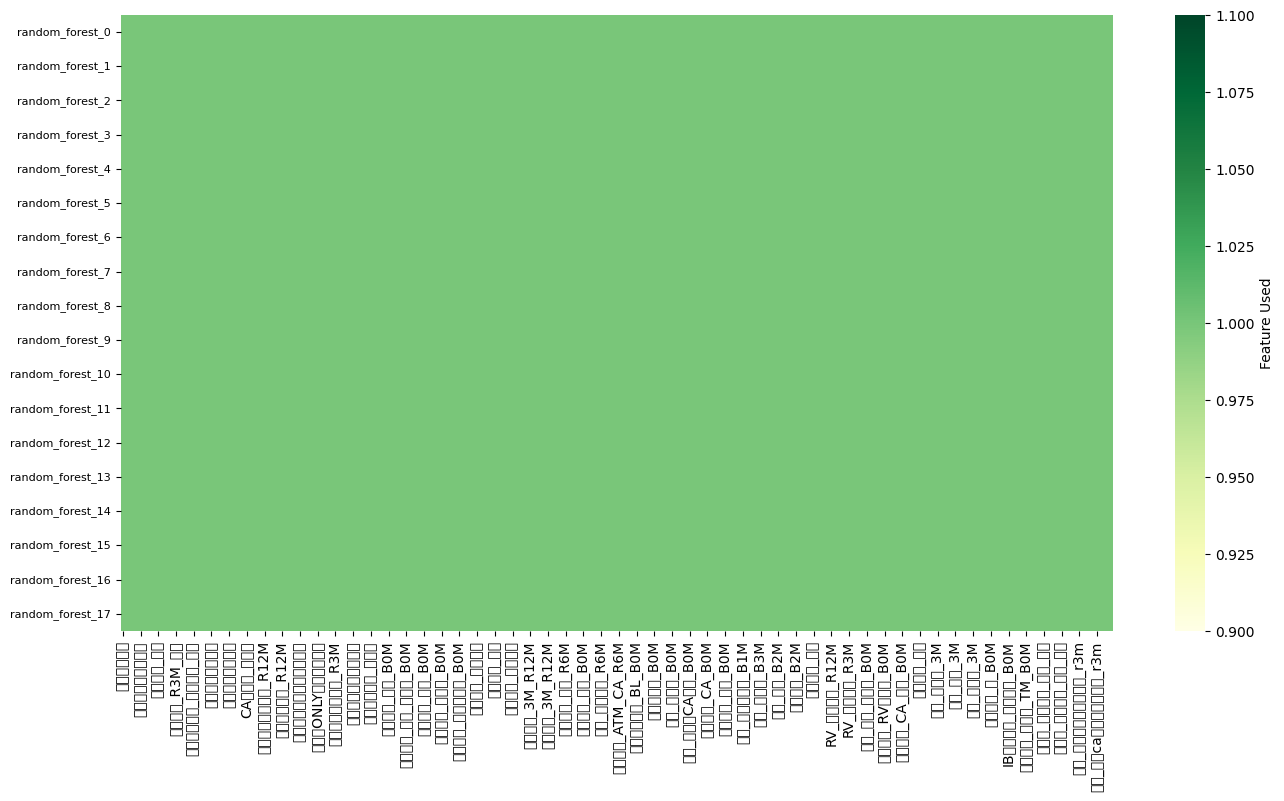

In [35]:
pipe.run_pipeline()

## 결과를 보면 CV Score가 3개의 묶음으로 비슷하다는 것을 알 수 있다.

## -> 조합 추측 가능 : max_features을 고정하고 max_samples을 순서대로 하나씩 총 3개를 진행.

,

## 각각의 RandomForest가 5번씩 진행했는데 그 값을 현재 알 수 없으니

## CV Score 값이 가장 작은 모델을 best_run으로 선정하면

## 가장 마지막 조합이 best_run 모델이 된다.

- n_estimator = 400, max_deep = 10, min_samples_leaf = 10max_feature(mtry) = [15], max_samples_(sample size) = [1]

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

# basic과 tuning을 비교

- basic = CV Score: -159779.2585 ± 694.0948

- tuning = CV Score: -158460.9561 ± 776.4553